# Phase 1 — Data Exploration
## IBM HR Employee Attrition Dataset
---


## 1. Problem Definition

### Domain
In This project We will build an **HR Attrition Advice System** , a binary classification system designed to predict whether an employee is at risk of leaving the organization.

### Problem Statement
Employee attrition is a persistent and costly challenge across all industries. When skilled employees leave unexpectedly, organizations face significant losses: recruitment and training costs, loss of institutional knowledge, reduced team morale, and decreased productivity. Despite all these well known consequences, most HR departments only react to attrition after it happens instead of preventing it from happening in the first place.

The core challenge is that attrition is driven by a complex mix of factors ( compensation, work-life balance, job satisfaction, career growth opportunities, and managerial relationships) making it difficult for HR teams to identify at risk employees using their intuition alone.

### Motivation
Machine learning will provide us with a data driven solution to this problem. By training on historical employee records, a classification model can learn which combinations of features are most predictive of departure, then flag at risk employees before they resign, this will give HR the opportunity to intervene with targeted retention strategies.

The practical output of this system is a binary advice signal:
- **Attrition = 1 (Yes):** This employee is at elevated risk of leaving → HR should investigate and consider intervention (e.g., compensation review, career development conversation, workload adjustment).
- **Attrition = 0 (No):** This employee is likely to stay → standard engagement monitoring is sufficient.



## 2. Dataset Selection & Justification

### Dataset Goal & Source
We use the **IBM HR Analytics Employee Attrition Dataset**, publicly available on Kaggle:

> **URL:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

This dataset was created by IBM data scientists specifically to study what drives employees to leave an organization. It contains 1,470 employee records and 35 features covering demographics, job details, satisfaction scores, and work history. The target variable is  (Yes/No), making it a binary classification problem that directly matches our system goal.


---

### Justification

#### Relevance
The dataset directly matches our problem definition. Every feature is a plausible driver of attrition. The target variable  is exactly what our system needs to predict. There is no feature engineering gap between what the dataset provides and what the problem requires.

#### Completeness
The IBM HR dataset contains no missing values across all 1,470 records. This is a significant advantage: it means we spend our preprocessing effort on meaningful transformations rather than imputation guesswork. The dataset is also comprehensive in its feature coverage as it captures demographic, organizational, and attitudinal dimensions of the employee experience simultaneously.

#### Quality
The dataset was created by IBM data scientists under controlled conditions, ensuring internal consistency (no contradictory records, no data entry errors). While it is synthetic, it was designed to reflect real world HR distributions and is one of the most widely benchmarked datasets in HR analytics research. Its synthetic origin also means there are no privacy concerns, making it appropriate for an academic setting.


---

### Data set Feature Summary

| Category | Features |
|---|---|
| **Demographics** | Age, Gender, MaritalStatus, Education, EducationField |
| **Job Details** | JobRole, Department, JobLevel, JobInvolvement |
| **Compensation** | MonthlyIncome, MonthlyRate, DailyRate, HourlyRate, StockOptionLevel |
| **Satisfaction & Balance** | JobSatisfaction, EnvironmentSatisfaction, RelationshipSatisfaction, WorkLifeBalance |
| **Work History** | YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, TotalWorkingYears |
| **Workload** | OverTime, BusinessTravel, NumCompaniesWorked, TrainingTimesLastYear |
| **Performance** | PerformanceRating, PercentSalaryHike, JobInvolvement |
| **Other** | DistanceFromHome, EmployeeNumber, EmployeeCount, Over18, StandardHours |
| **Target** | Attrition |

## 3. Exploratory Data Analysis (EDA)

### Dataset Overview

The dataset used in this project is the **IBM HR Analytics Employee Attrition Dataset**, which contains:

- **Observations:** 1,470 employee records
- **Features:** 35 columns (reduced to 31 after dropping constant/ID columns)
- **Data Types:**
  - Numerical (int64): Age, MonthlyIncome, YearsAtCompany, TotalWorkingYears, etc.
  - Categorical (object): Department, JobRole, BusinessTravel, MaritalStatus, etc.

- **Target Variable:** `Attrition`
  - **Type:** Binary classification
  - **Classes:**
    - `No` (0) — Employee stayed → **1,233 employees (83.9%)**
    - `Yes` (1) — Employee left → **273 employees (16.1%)**


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')

# Dataset overview to check observations, features, and data types
print(df.info())

# Statistical Summary for numerical features such as mean, std, min/max
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

---
### 1 — Class Distribution
The primary goal of this visualization is to define the project scope. By analyzing the distribution Attrition distribution, we can identify the presence class imbalance. This step is important for selecting appropriate evaluation metrics and for better understanding model performance.

**Why a Bar and Pie Charts?**
To provide both frequency counts and proportional percentages, which is essential for identifying the class imbalance that will dictate our model evaluation strategy.


**Findings:**
The dataset is Imbalanced as 1,233 employees (83.9%) didn't leave the company, while 273 employees (16.1%) did leave.




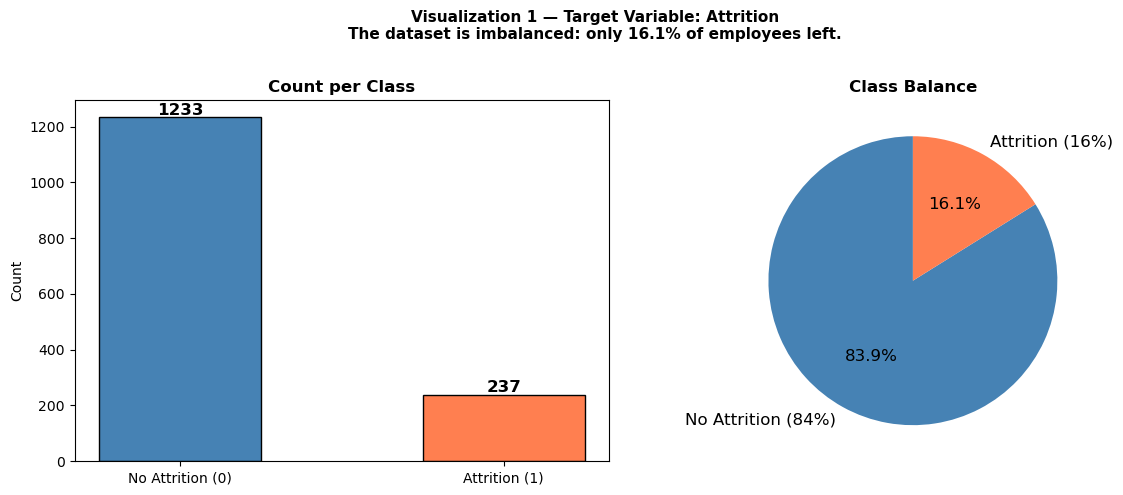

Visualization 1 saved.


In [2]:
# VISUALIZATION 1: Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Attrition'].value_counts()
axes[0].bar(['No Attrition (0)', 'Attrition (1)'], counts.values,
            color=['steelblue', 'coral'], edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Attrition (84%)', 'Attrition (16%)'],
            colors=['steelblue', 'coral'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=12, fontweight='bold')

plt.suptitle(
    'Visualization 1 — Target Variable: Attrition\n'
    'The dataset is imbalanced: only 16.1% of employees left.\n',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 1 saved.')

---
### 2 — Feature Correlation Heatmap
The objective of this visualization is to understand the relationships between numerical features. By analyzing how numerical features relate to each other, we can identify which variables are most relevant for predicting the employee behavior and detect potential redundancy between features.

**Why a Correlation heatmap?**
It is the standard tool for identifying linear relationships, helping to justify the removal of redundant variables.

**Findings:**
1. The heatmap shows the correlation coefficient between variables, ranging from -1.0 (strong negative correlation) to 1.0 (strong positive correlation).
2. The diagonal represents each variable's correlation with itself.
3. Light Orange/Red Clusters indicate a strong positive correlations. 
4. Blue Areas represent Low or Zero correlation.

In this dataset, there is a strong positive correlation between (YearsAtCompany and YearsSinceLastPromotion).


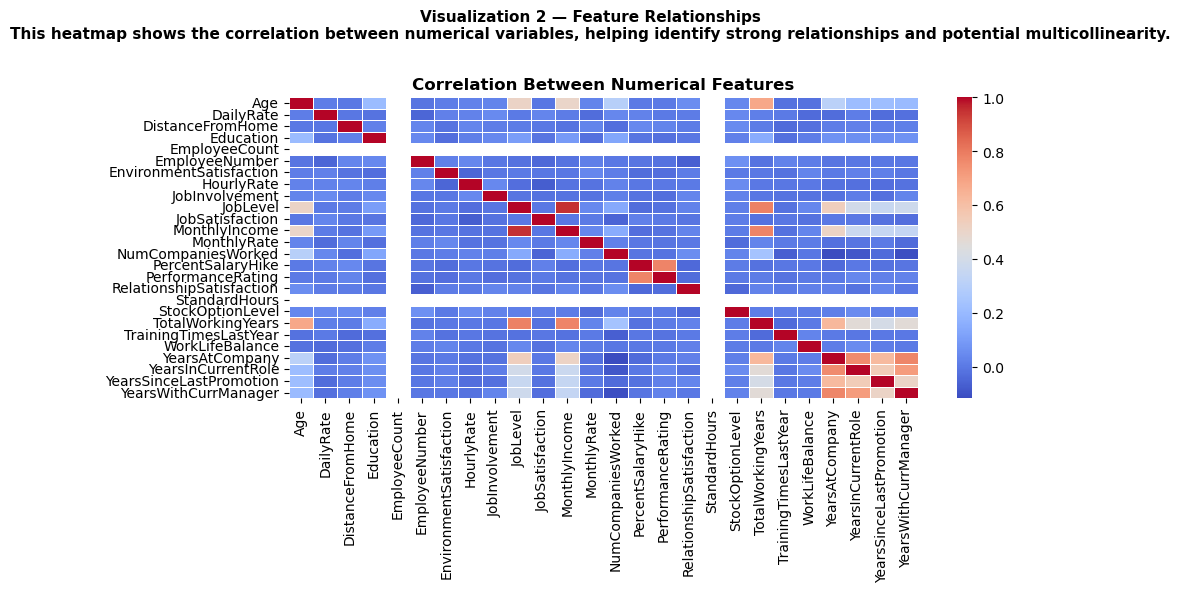

Visualization 2 saved.


In [3]:
# VISUALIZATION 2: Correlation Matrix for Numerical Features.
fig, ax = plt.subplots(figsize=(10, 6))
# Computing the correlation matrix for numeric features only.
corr= df.corr(numeric_only=True)
# Plot Heatmap
sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    cbar=True,
    ax=ax
)
ax.set_title('Correlation Between Numerical Features', fontsize=12, fontweight='bold')

plt.suptitle(
    'Visualization 2 — Feature Relationships\n'
    'This heatmap shows the correlation between numerical variables, helping identify strong relationships and potential multicollinearity.\n',
    fontsize=11,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Visualization 2 saved.')

---
### 3 — Missing Value Visualization
The main objective of this step is to assess the completeness and quality of the dataset. Missing values can lead to errors during model training and may bias the results if not handled properly. Therefore, it is important to identify them before proceeding with data preprocessing.

**Why a heatmap?**
It provides a comprehensive visual summary of the entire dataset, allowing for the detection of any data gaps across features.

**Findings:**
The dataset is complete and contains no missing values, indicating high data quality and reliability.

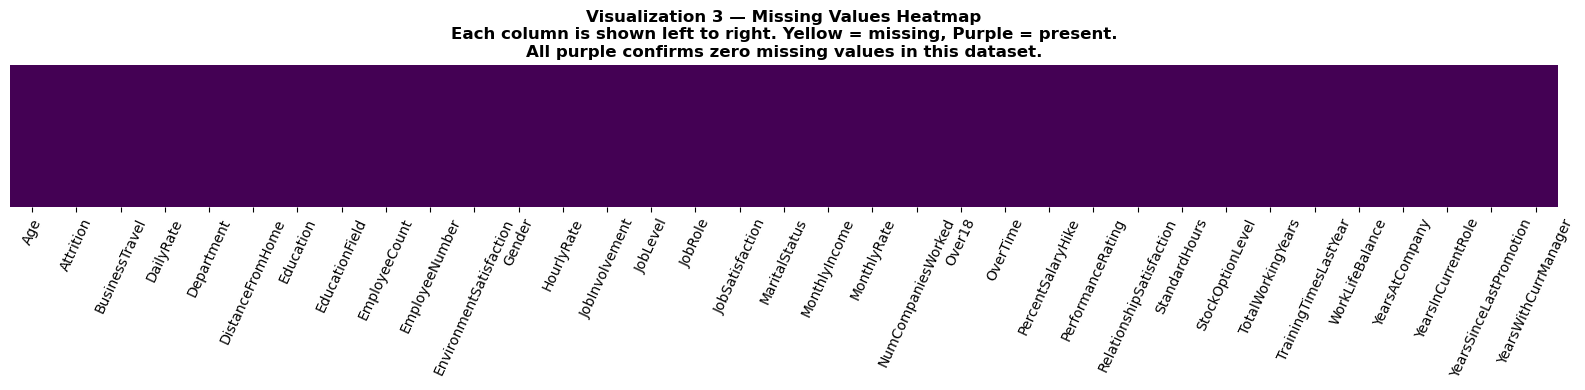

Visualization 3 saved.


In [4]:
# VISUALIZATION 3: Missing Values Heatmap
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax, yticklabels=False)
ax.set_title(
    'Visualization 3 — Missing Values Heatmap\n'
    'Each column is shown left to right. Yellow = missing, Purple = present.\n'
    'All purple confirms zero missing values in this dataset.',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=65)
plt.tight_layout()
plt.savefig('plots/viz3_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')

---
### 4 —  Feature vs Target Relationship
Since the goal is to develop a classification system that provides guidance, it is important to analyze the relationship between features and the target variable (Attrition). Visualizing relationships such as *JobSatisfaction* versus *Attrition* helps us interpret the results and understand how specific factors influence employee behavior.

**Why a Categorical Count Plot?**
It illustrates the ratio of attrition across discrete categories.

**Findings:**
The visualization shows how different levels of job satisfaction are associated with employee attrition, providing insights whether higher satisfaction contributes to a lower likelihood of leaving 


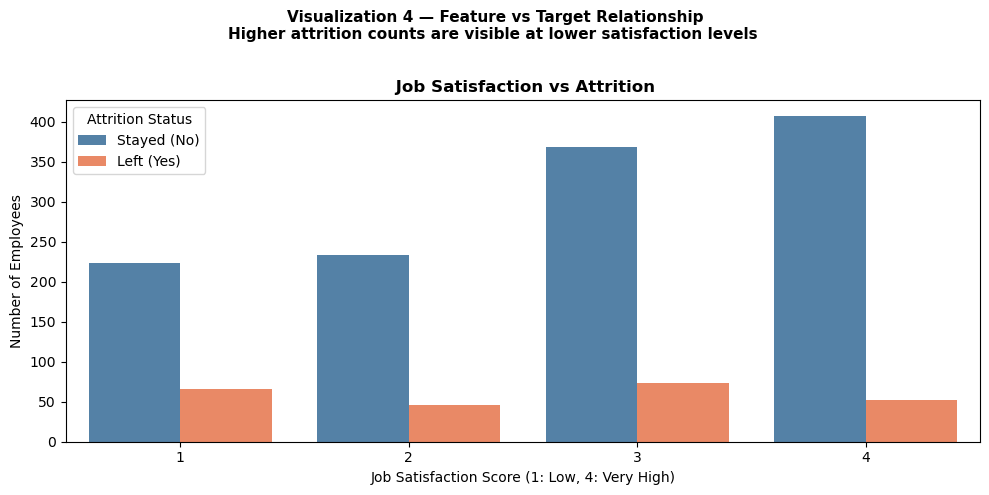

Visualization 4 saved.


In [5]:
# VISUALIZATION 4: Job Satisfaction vs Attrition
fig, ax = plt.subplots(figsize=(10, 5))

# Count Plot
sns.countplot(
    x='JobSatisfaction',
    hue='Attrition',
    data=df,
    palette=['steelblue', 'coral'],
    ax=ax
)

plt.title(' Job Satisfaction vs Attrition',fontsize=12, fontweight='bold')
plt.xlabel('Job Satisfaction Score (1: Low, 4: Very High)')
plt.ylabel('Number of Employees')
plt.legend(title='Attrition Status', labels=['Stayed (No)', 'Left (Yes)'])
plt.suptitle(
    'Visualization 4 — Feature vs Target Relationship\n'
    'Higher attrition counts are visible at lower satisfaction levels \n',
    fontsize=11,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('plots/viz4_job_satisfaction_vs_attrition.png', bbox_inches='tight')
plt.show()
print('Visualization 4 saved.')

## 4. Preprocessing Pipeline

### 0 — Imports & Setup

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
os.makedirs('plots', exist_ok=True)

print('All libraries imported successfully.')

All libraries imported successfully.


---
### 1 — Load Dataset
> Download `WA_Fn-UseC_-HR-Employee-Attrition.csv` from Kaggle:  
> https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
> Place it in the same directory as this notebook, then run the cell below.

In [7]:
df_raw = pd.read_csv('Dataset/Raw_Kaggle_HR_Employee_Attrition_data.csv')
print(f'Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


---
### 2 — Initial Data Inspection

In [8]:
print('=== Shape ===')
print(f'{df_raw.shape[0]} rows, {df_raw.shape[1]} columns')

print('\n=== Data Types ===')
print(df_raw.dtypes)

print('\n=== Statistical Summary ===')
df_raw.describe(include='all')

=== Shape ===
1470 rows, 35 columns

=== Data Types ===
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470.000000,1470,1470.000000,1470.000000,1470.000000,1470,1470,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,NaN,2,NaN,NaN,NaN,9,NaN,3,NaN,NaN,NaN,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,NaN,Male,NaN,NaN,NaN,Sales Executive,NaN,Married,NaN,NaN,NaN,Y,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,NaN,882,NaN,NaN,NaN,326,NaN,673,NaN,NaN,NaN,1470,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,2.721769,NaN,65.891156,2.729932,2.063946,NaN,2.728571,NaN,6502.931293,14313.103401,2.693197,NaN,NaN,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,1.093082,NaN,20.329428,0.711561,1.106940,NaN,1.102846,NaN,4707.956783,7117.786044,2.498009,NaN,NaN,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,1.000000,NaN,30.000000,1.000000,1.000000,NaN,1.000000,NaN,1009.000000,2094.000000,0.000000,NaN,NaN,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,2.000000,NaN,48.000000,2.000000,1.000000,NaN,2.000000,NaN,2911.000000,8047.000000,1.000000,NaN,NaN,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,3.000000,NaN,66.000000,3.000000,2.000000,NaN,3.000000,NaN,4919.000000,14235.500000,2.000000,NaN,NaN,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,4.000000,NaN,83.750000,3.000000,3.000000,NaN,4.000000,NaN,8379.000000,20461.500000,4.000000,NaN,NaN,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


---
### 3 — CLEANING & PRUNING

#### 3.1 — Drop Constant Columns

**Why we do this:**  
Some columns in the IBM HR dataset carry absolutely no information because they have the same value for every single employee. A machine learning model cannot learn anything from a feature that never changes — it contributes zero variance and only adds noise.

**Columns dropped and why:**
- **`EmployeeCount`** — always equals 1. It was included by IBM to count employees in aggregations, not as a predictive feature.
- **`Over18`** — always equals 'Y'. All employees in this dataset are over 18, so this column is meaningless.
- **`StandardHours`** — always equals 80. This represents the standard work week and is the same for everyone.
- **`EmployeeNumber`** — a unique ID assigned to each employee. It has no relationship with attrition; it is just a row identifier.

In [9]:
# Automatically detect constant columns (nunique == 1)
constant_cols = [col for col in df_raw.columns if df_raw[col].nunique() <= 1]
id_cols = ['EmployeeNumber']
cols_to_drop = constant_cols + id_cols

print('=== Columns Being Dropped ===')
for col in cols_to_drop:
    reason = 'Constant — zero variance' if col in constant_cols else 'Unique ID — not a feature'
    print(f'  {col}: {reason} | unique values = {df_raw[col].nunique()}')

df = df_raw.drop(columns=cols_to_drop)
print(f'\nBefore: {df_raw.shape[1]} columns → After: {df.shape[1]} columns')

=== Columns Being Dropped ===
  EmployeeCount: Constant — zero variance | unique values = 1
  Over18: Constant — zero variance | unique values = 1
  StandardHours: Constant — zero variance | unique values = 1
  EmployeeNumber: Unique ID — not a feature | unique values = 1470

Before: 35 columns → After: 31 columns


#### 3.2 — Missing Value Analysis

**Why we check this:**  
Missing values can cause errors during model training and can silently bias results if not addressed. We must identify them before any further preprocessing.

**Finding:**  
The IBM HR dataset is a synthetic dataset created by IBM data scientists, so it contains no missing values. However, we still include this check because:
1. It is good practice to always verify — never assume.
2. If this pipeline is ever run on real HR data, the check and the imputation logic in the pipeline will handle missing values automatically.

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Count': missing, 'Percent %': missing_pct})
missing_with_values = missing_summary[missing_summary['Count'] > 0]

if missing_with_values.empty:
    print('No missing values found across all 31 columns.')
    print('The IBM HR dataset is complete — no imputation needed.')
else:
    print('Missing values detected:')
    print(missing_with_values)

No missing values found across all 31 columns.
The IBM HR dataset is complete — no imputation needed.


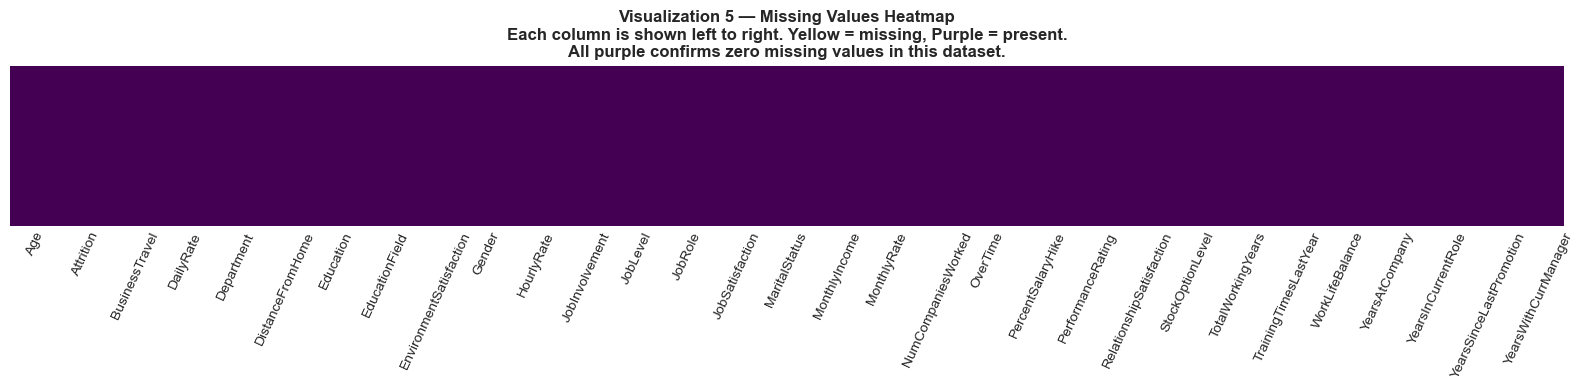

Visualization 5 saved.


In [11]:
# VISUALIZATION 5: Missing Values Heatmap
fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', ax=ax, yticklabels=False)
ax.set_title(
    'Visualization 5 — Missing Values Heatmap\n'
    'Each column is shown left to right. Yellow = missing, Purple = present.\n'
    'All purple confirms zero missing values in this dataset.',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=65)
plt.tight_layout()
plt.savefig('plots/viz5_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 5 saved.')

#### 3.3 — Target Variable Encoding: Attrition → Binary (0 / 1)

**Why we do this:**  
The target column `Attrition` is stored as text ('Yes' / 'No'). Machine learning algorithms require numeric inputs, so we convert it to a binary integer:
- `Yes` → `1` (employee left the company)
- `No` → `0` (employee stayed)

**Why we use manual mapping instead of LabelEncoder:**  
LabelEncoder assigns 0/1 alphabetically, which would make `No = 0` and `Yes = 1` — correct in this case, but not guaranteed for all datasets. Using an explicit `.map()` makes our intent clear and removes ambiguity.

In [12]:
print('Before encoding:')
print(df['Attrition'].value_counts())
print(f'Data type: {df["Attrition"].dtype}')

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print('\nAfter encoding:')
print(df['Attrition'].value_counts())
print(f'Data type: {df["Attrition"].dtype}')
print(f'Attrition rate: {df["Attrition"].mean()*100:.1f}% of employees left')

Before encoding:
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Data type: object

After encoding:
Attrition
0    1233
1     237
Name: count, dtype: int64
Data type: int64
Attrition rate: 16.1% of employees left


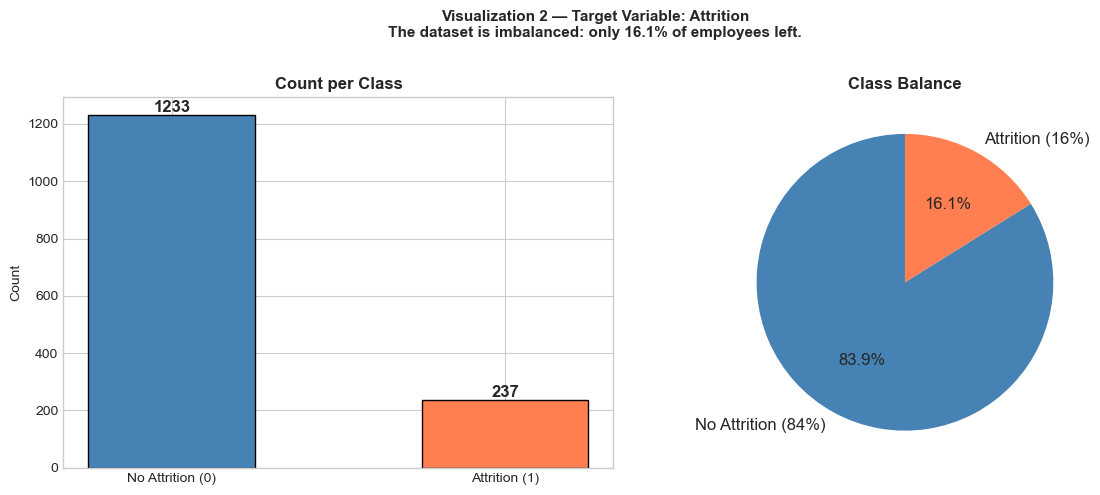

Visualization 2 saved.


In [13]:
# VISUALIZATION 2: Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['Attrition'].value_counts()
axes[0].bar(['No Attrition (0)', 'Attrition (1)'], counts.values,
            color=['steelblue', 'coral'], edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Count per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Attrition (84%)', 'Attrition (16%)'],
            colors=['steelblue', 'coral'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Class Balance', fontsize=12, fontweight='bold')

plt.suptitle(
    'Visualization 2 — Target Variable: Attrition\n'
    'The dataset is imbalanced: only 16.1% of employees left.\n',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 2 saved.')

---
### 4 — CATEGORICAL DATA — One-Hot Encoding

**Why One-Hot Encoding (OHE)?**  
Some categorical features are **nominal** — they have multiple categories with no natural order or ranking between them. If we assigned numbers directly (e.g., Sales=1, R&D=2, HR=3), the model would wrongly interpret this as R&D being "twice" Sales and HR being "three times" Sales. This would introduce a false numerical relationship that does not exist.

One-Hot Encoding solves this by creating a separate binary column for each category. Each column is either 0 or 1, and no ordering is implied.

**Columns encoded with OHE and why:**

| Column | Categories | Why OHE |
|--------|-----------|--------|
| `Department` | Sales, R&D, HR | No meaningful rank between departments |
| `EducationField` | Life Sciences, Medical, Marketing, etc. | No ordering between fields of study |
| `JobRole` | Manager, Scientist, Technician, etc. | No ordering between job roles |
| `MaritalStatus` | Single, Married, Divorced | No ordering between marital statuses |


In [14]:
ohe_cols = ['Department', 'EducationField', 'JobRole', 'MaritalStatus']

print('=== Unique values per column (confirming they are nominal) ===')
for col in ohe_cols:
    print(f'  {col} ({df[col].nunique()} categories): {sorted(df[col].unique())}')

=== Unique values per column (confirming they are nominal) ===
  Department (3 categories): ['Human Resources', 'Research & Development', 'Sales']
  EducationField (6 categories): ['Human Resources', 'Life Sciences', 'Marketing', 'Medical', 'Other', 'Technical Degree']
  JobRole (9 categories): ['Healthcare Representative', 'Human Resources', 'Laboratory Technician', 'Manager', 'Manufacturing Director', 'Research Director', 'Research Scientist', 'Sales Executive', 'Sales Representative']
  MaritalStatus (3 categories): ['Divorced', 'Married', 'Single']


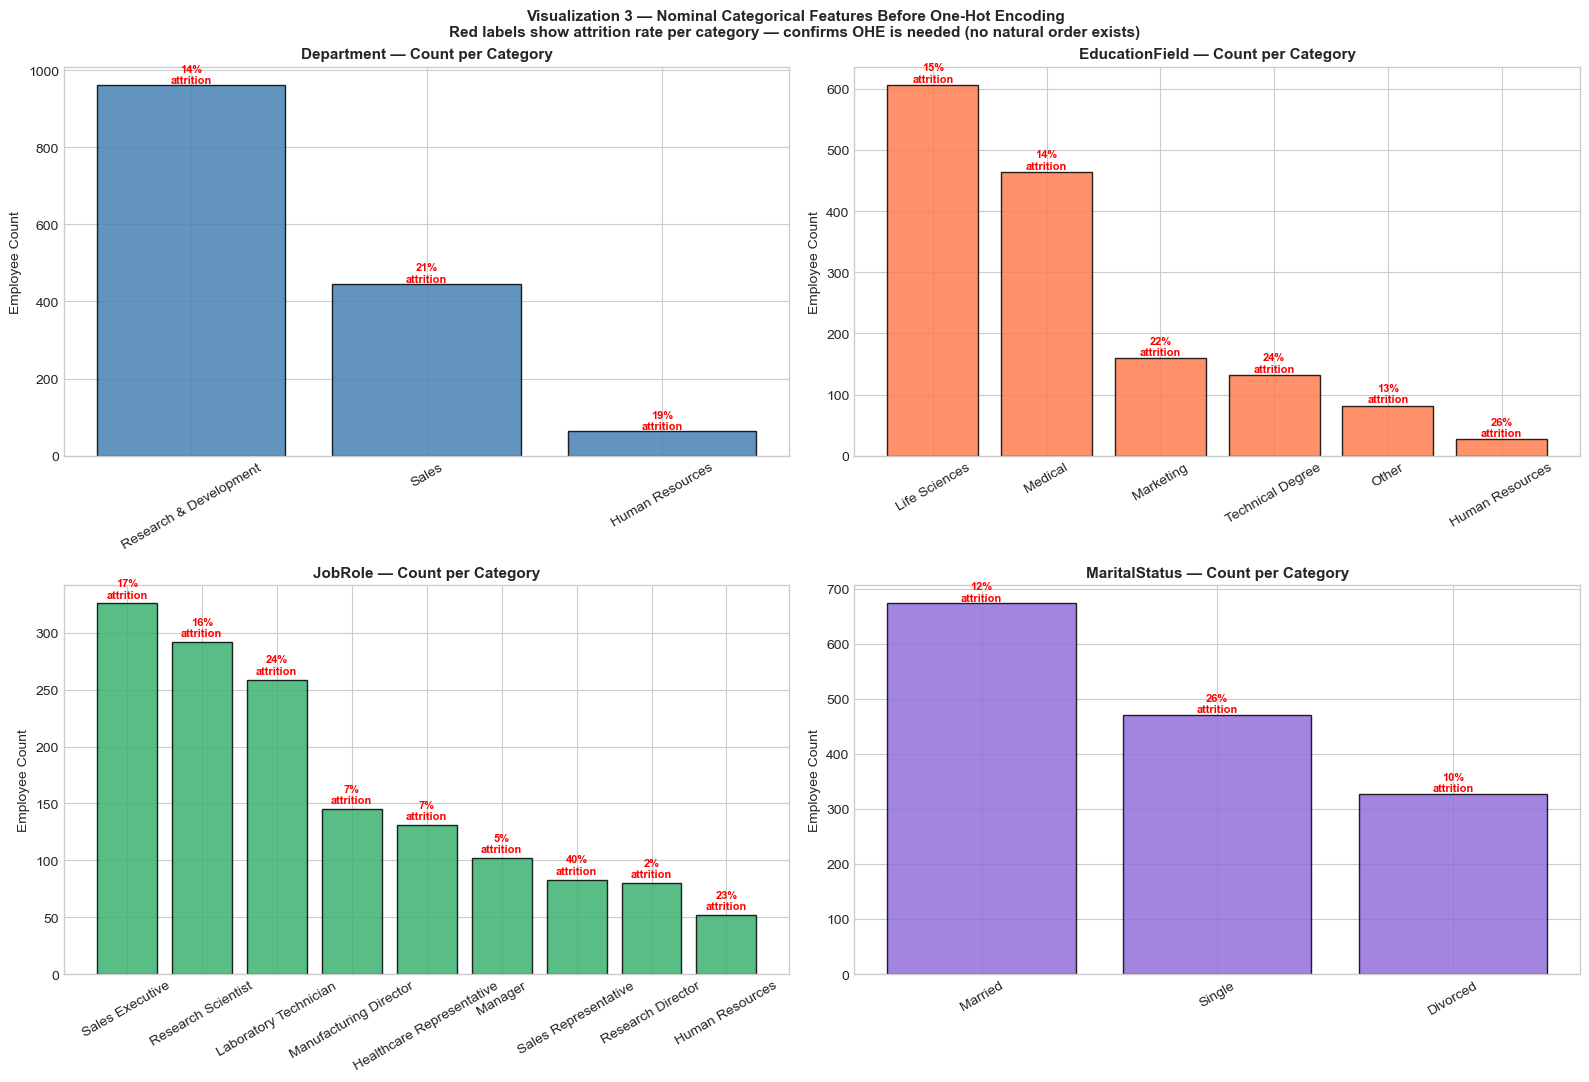

Visualization 3 saved.


In [15]:
# VISUALIZATION 3: Categorical distributions with attrition rate overlay
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

for i, col in enumerate(ohe_cols):
    counts = df[col].value_counts()
    bars = axes[i].bar(counts.index, counts.values, color=colors[i], edgecolor='black', alpha=0.85)
    axes[i].set_title(f'{col} — Count per Category', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Employee Count')
    axes[i].tick_params(axis='x', rotation=30)
    # Overlay attrition rate as red percentage label
    for j, cat in enumerate(counts.index):
        rate = df[df[col] == cat]['Attrition'].mean() * 100
        axes[i].text(j, counts[cat] + 5, f'{rate:.0f}%\nattrition',
                     ha='center', fontsize=8, color='red', fontweight='bold')

plt.suptitle(
    'Visualization 3 — Nominal Categorical Features Before One-Hot Encoding\n'
    'Red labels show attrition rate per category — confirms OHE is needed (no natural order exists)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz3_categorical_before_ohe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 3 saved.')

In [16]:
# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=ohe_cols, drop_first=False)

new_ohe_cols = [c for c in df.columns if any(c.startswith(p + '_') for p in ohe_cols)]

print(f'One-Hot Encoding applied.')
print(f'New binary columns created ({len(new_ohe_cols)}):')
for col in new_ohe_cols:
    print(f'  {col}: unique values = {sorted(df[col].unique())}')
print(f'\nDataset shape after OHE: {df.shape}')

One-Hot Encoding applied.
New binary columns created (21):
  Department_Human Resources: unique values = [False, True]
  Department_Research & Development: unique values = [False, True]
  Department_Sales: unique values = [False, True]
  EducationField_Human Resources: unique values = [False, True]
  EducationField_Life Sciences: unique values = [False, True]
  EducationField_Marketing: unique values = [False, True]
  EducationField_Medical: unique values = [False, True]
  EducationField_Other: unique values = [False, True]
  EducationField_Technical Degree: unique values = [False, True]
  JobRole_Healthcare Representative: unique values = [False, True]
  JobRole_Human Resources: unique values = [False, True]
  JobRole_Laboratory Technician: unique values = [False, True]
  JobRole_Manager: unique values = [False, True]
  JobRole_Manufacturing Director: unique values = [False, True]
  JobRole_Research Director: unique values = [False, True]
  JobRole_Research Scientist: unique values = 

---
### 5 — NUMERICAL DATA — Scaling / Normalization

**Why we scale continuous features?**  
Many machine learning algorithms are sensitive to the scale of input features:
- **SVM** uses distances between points — a feature with range 1–20,000 (MonthlyIncome) would completely dominate a feature with range 1–5 (JobLevel) without scaling.
- **KNN** computes Euclidean distance — same problem as SVM.
- **Neural Networks** converge much faster and more reliably when inputs are on the same scale.
- **Logistic Regression** is affected by feature magnitude when regularization is applied.

**Why StandardScaler specifically?**  
StandardScaler transforms each feature to have **mean = 0 and standard deviation = 1**. This is appropriate here because the features are not perfectly normally distributed, but the z-score transformation preserves the shape of each distribution while putting all features on the same scale.

**Why not MinMaxScaler?**  
MinMaxScaler is sensitive to outliers — a single extreme value compresses all other values into a small range. Since we handle outliers separately in Section 9, StandardScaler is the safer choice here.


In [17]:
# Identify continuous numeric columns to scale
# Exclude: target (Attrition), OHE columns, and low-cardinality ordinal columns
exclude_from_scaling = ['Attrition'] + new_ohe_cols
low_cardinality = [c for c in df.select_dtypes(include=[np.number]).columns
                   if df[c].nunique() <= 5 and c not in exclude_from_scaling]
continuous_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                   if c not in exclude_from_scaling and c not in low_cardinality]

print(f'Columns to scale ({len(continuous_cols)}):')
for c in continuous_cols:
    print(f'  {c}: min={df[c].min():.1f}, max={df[c].max():.1f}, mean={df[c].mean():.1f}')

Columns to scale (14):
  Age: min=18.0, max=60.0, mean=36.9
  DailyRate: min=102.0, max=1499.0, mean=802.5
  DistanceFromHome: min=1.0, max=29.0, mean=9.2
  HourlyRate: min=30.0, max=100.0, mean=65.9
  MonthlyIncome: min=1009.0, max=19999.0, mean=6502.9
  MonthlyRate: min=2094.0, max=26999.0, mean=14313.1
  NumCompaniesWorked: min=0.0, max=9.0, mean=2.7
  PercentSalaryHike: min=11.0, max=25.0, mean=15.2
  TotalWorkingYears: min=0.0, max=40.0, mean=11.3
  TrainingTimesLastYear: min=0.0, max=6.0, mean=2.8
  YearsAtCompany: min=0.0, max=40.0, mean=7.0
  YearsInCurrentRole: min=0.0, max=18.0, mean=4.2
  YearsSinceLastPromotion: min=0.0, max=15.0, mean=2.2
  YearsWithCurrManager: min=0.0, max=17.0, mean=4.1


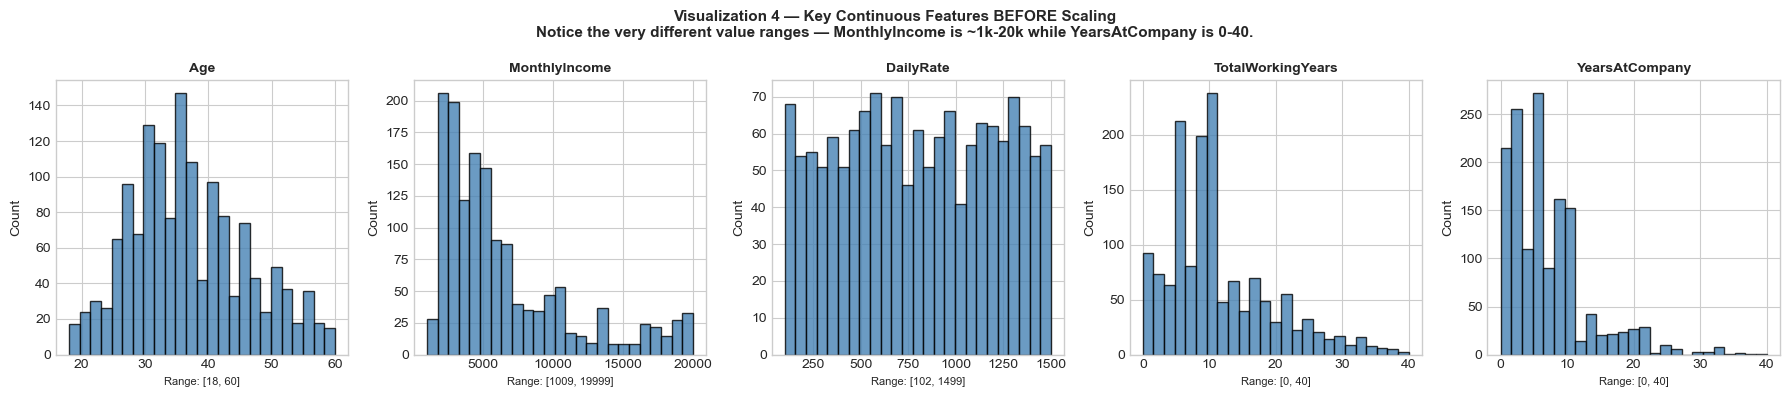

Visualization 4 saved.


In [18]:
# VISUALIZATION 4: Before scaling — key continuous features
key_cols = ['Age', 'MonthlyIncome', 'DailyRate', 'TotalWorkingYears', 'YearsAtCompany']

fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 4))
for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'Range: [{df[col].min():.0f}, {df[col].max():.0f}]', fontsize=8)
    axes[i].set_ylabel('Count')
plt.suptitle(
    'Visualization 4 — Key Continuous Features BEFORE Scaling\n'
    'Notice the very different value ranges — MonthlyIncome is ~1k-20k while YearsAtCompany is 0-40.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz4_before_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 4 saved.')

In [19]:
# Apply StandardScaler
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print('StandardScaler applied.')
print('\nVerification — mean and std after scaling:')
for c in continuous_cols:
    print(f'  {c}: mean={df[c].mean():.4f} (should be ~0), std={df[c].std():.4f} (should be ~1)')

StandardScaler applied.

Verification — mean and std after scaling:
  Age: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  DailyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  DistanceFromHome: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  HourlyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  MonthlyIncome: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  MonthlyRate: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  NumCompaniesWorked: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  PercentSalaryHike: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  TotalWorkingYears: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  TrainingTimesLastYear: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsAtCompany: mean=-0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsInCurrentRole: mean=0.0000 (should be ~0), std=1.0003 (should be ~1)
  YearsSinceLastPromotion: mean=0.0000 (should be ~0), std=1.0003

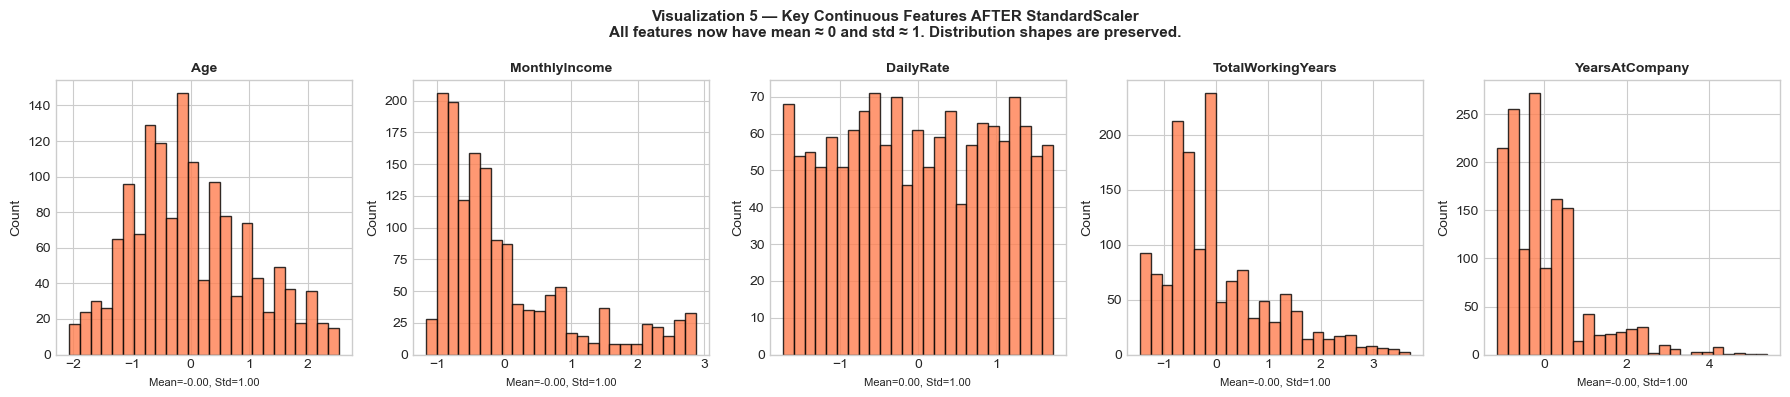

Visualization 5 saved.


In [20]:
# VISUALIZATION 5: After scaling — same features now on same scale
fig, axes = plt.subplots(1, len(key_cols), figsize=(18, 4))
for i, col in enumerate(key_cols):
    axes[i].hist(df[col], bins=25, color='coral', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel(f'Mean={df[col].mean():.2f}, Std={df[col].std():.2f}', fontsize=8)
    axes[i].set_ylabel('Count')
plt.suptitle(
    'Visualization 5 — Key Continuous Features AFTER StandardScaler\n'
    'All features now have mean ≈ 0 and std ≈ 1. Distribution shapes are preserved.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz5_after_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 5 saved.')

---
### 6 — NEW FEATURES — Ratio Features

**Why create new features?**  
Raw features sometimes hide important relationships. Ratio features capture the *relationship between two variables*, which can be far more predictive than either variable alone. For example, an employee who has not been promoted in 3 years at a company where they have worked for 4 years tells a very different story than someone who has not been promoted in 3 years but has only worked there for 3 years.

**Features created and their reasoning:**

| New Feature | Formula | Why it matters |
|-------------|---------|----------------|
| `PromotionRatio` | YearsSinceLastPromotion / (YearsAtCompany + 1) | Measures career stagnation relative to tenure. High value = employee has waited a long time for promotion → strong attrition signal |
| `IncomePerYear` | MonthlyIncome / (TotalWorkingYears + 1) | Measures whether pay matches experience. Low value = underpaid for experience → salary dissatisfaction risk |
| `RoleStabilityRatio` | YearsInCurrentRole / (YearsAtCompany + 1) | Measures how long someone has stayed in the same role relative to total tenure. Very low = frequent role changes; very high = stuck in same role |

> **Note:** We add +1 to all denominators to prevent division-by-zero for new employees with 0 years at the company.

In [21]:
# Use raw values from df_raw for ratio calculations (before scaling distorts the values)
df['PromotionRatio']    = df_raw['YearsSinceLastPromotion'] / (df_raw['YearsAtCompany'] + 1)
df['IncomePerYear']     = df_raw['MonthlyIncome']           / (df_raw['TotalWorkingYears'] + 1)
df['RoleStabilityRatio']= df_raw['YearsInCurrentRole']      / (df_raw['YearsAtCompany'] + 1)

ratio_cols = ['PromotionRatio', 'IncomePerYear', 'RoleStabilityRatio']

print('Ratio features created:')
for col in ratio_cols:
    attr_mean    = df[df['Attrition'] == 1][col].mean()
    no_attr_mean = df[df['Attrition'] == 0][col].mean()
    print(f'  {col}:')
    print(f'    Mean (Attrition=1): {attr_mean:.3f}')
    print(f'    Mean (Attrition=0): {no_attr_mean:.3f}')
    print(f'    Difference: {abs(attr_mean - no_attr_mean):.3f} — {"good signal" if abs(attr_mean - no_attr_mean) > 0.05 else "weak signal"}')

Ratio features created:
  PromotionRatio:
    Mean (Attrition=1): 0.243
    Mean (Attrition=0): 0.235
    Difference: 0.008 — weak signal
  IncomePerYear:
    Mean (Attrition=1): 651.007
    Mean (Attrition=0): 575.383
    Difference: 75.624 — good signal
  RoleStabilityRatio:
    Mean (Attrition=1): 0.382
    Mean (Attrition=0): 0.500
    Difference: 0.117 — good signal


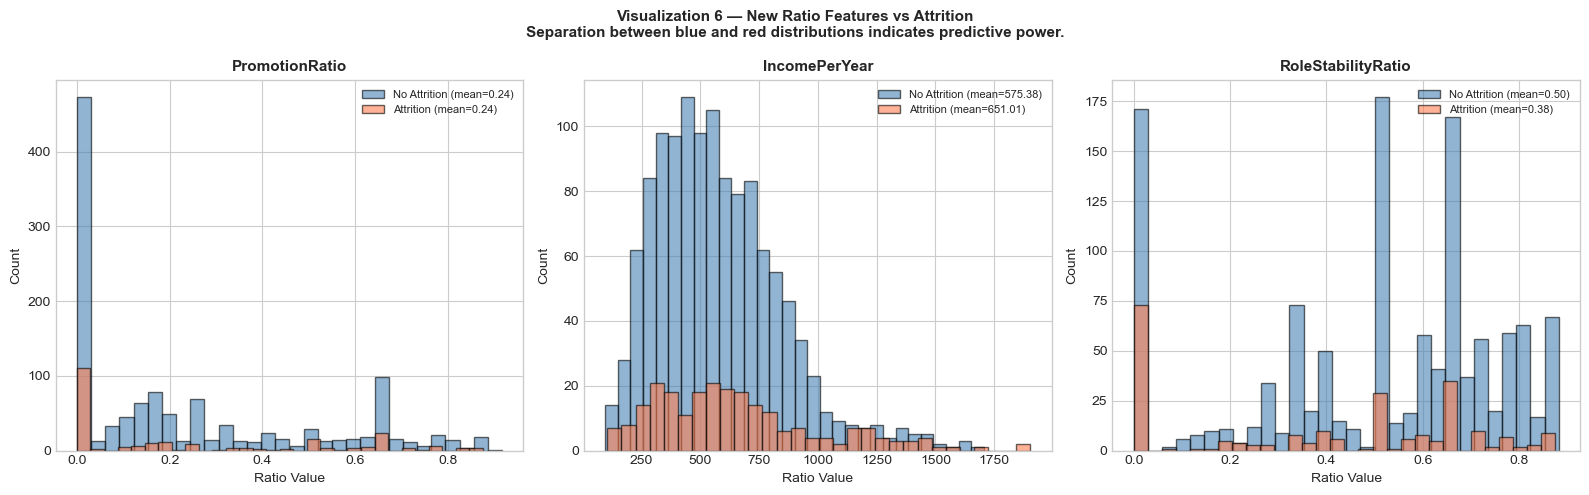

Visualization 6 saved.


In [22]:
# VISUALIZATION 6: Ratio features by Attrition group
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(ratio_cols):
    no_attr  = df[df['Attrition'] == 0][col]
    yes_attr = df[df['Attrition'] == 1][col]
    axes[i].hist(no_attr,  bins=30, alpha=0.6, color='steelblue', edgecolor='black', label=f'No Attrition (mean={no_attr.mean():.2f})')
    axes[i].hist(yes_attr, bins=30, alpha=0.6, color='coral',     edgecolor='black', label=f'Attrition (mean={yes_attr.mean():.2f})')
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Ratio Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle(
    'Visualization 6 — New Ratio Features vs Attrition\n'
    'Separation between blue and red distributions indicates predictive power.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz6_ratio_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 6 saved.')

---
### 7 — VISUALIZATIONS — Exploratory Analysis

**Why these visualizations?**  
The project requires the Preprocessing & Visualization Team to produce visualizations that help understand the data and justify preprocessing decisions. The following plots serve specific analytical purposes:
- The **correlation heatmap** identifies which features are most related to attrition, guiding feature selection in Part B.
- The **box plots** show how the top features differ between employees who left vs. stayed.
- The **JobRole attrition chart** shows which roles carry the highest turnover risk, validating our OHE decision.

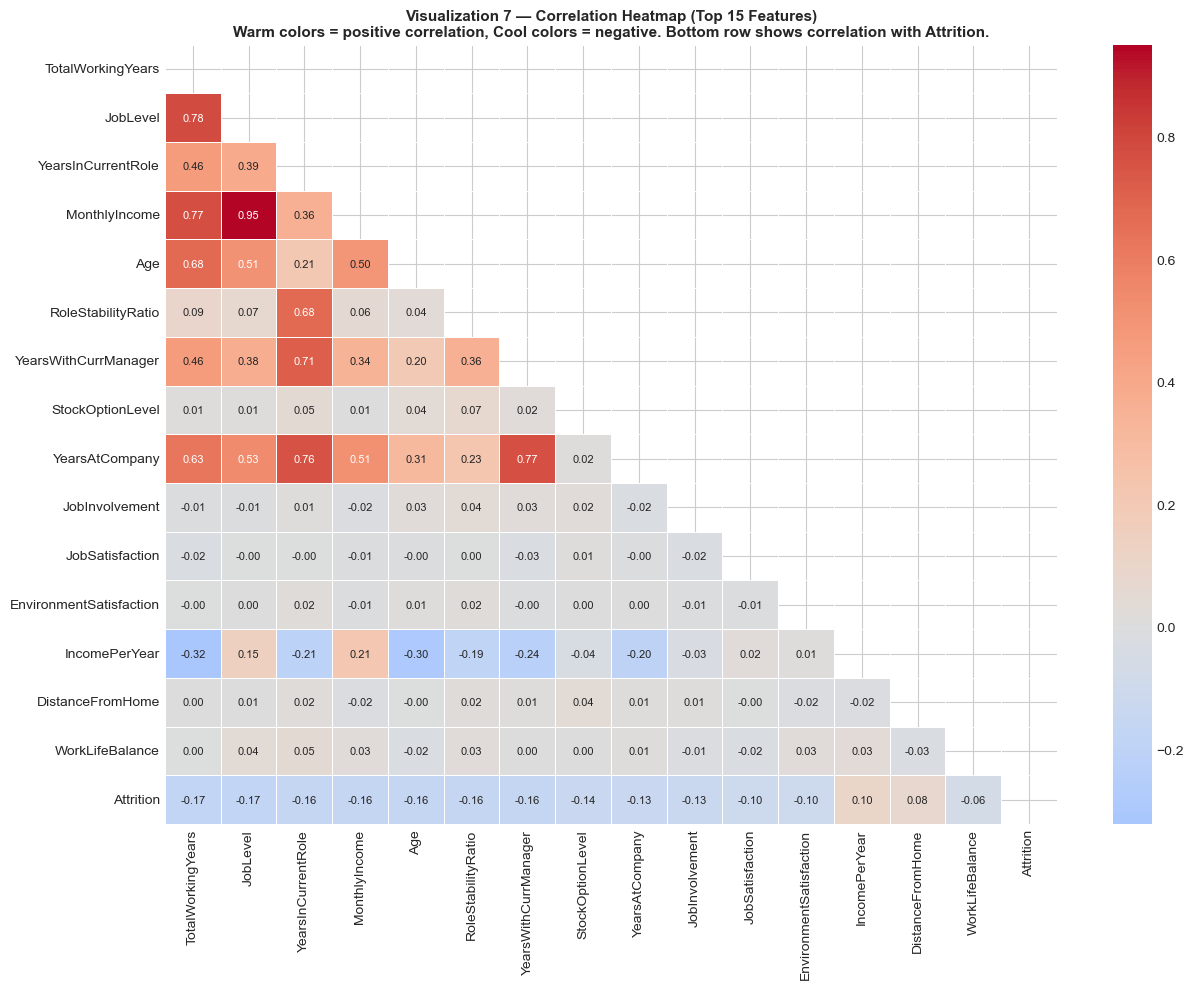

Visualization 7 saved.


In [23]:
# VISUALIZATION 7: Correlation Heatmap — top features correlated with Attrition
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()['Attrition'].drop('Attrition').abs().sort_values(ascending=False)
top15 = corr_with_target.head(15).index.tolist()

fig, ax = plt.subplots(figsize=(13, 10))
corr_matrix = numeric_df[top15 + ['Attrition']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, mask=mask, linewidths=0.5, annot_kws={'size': 8})
ax.set_title(
    'Visualization 7 — Correlation Heatmap (Top 15 Features)\n'
    'Warm colors = positive correlation, Cool colors = negative. Bottom row shows correlation with Attrition.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz7_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 7 saved.')

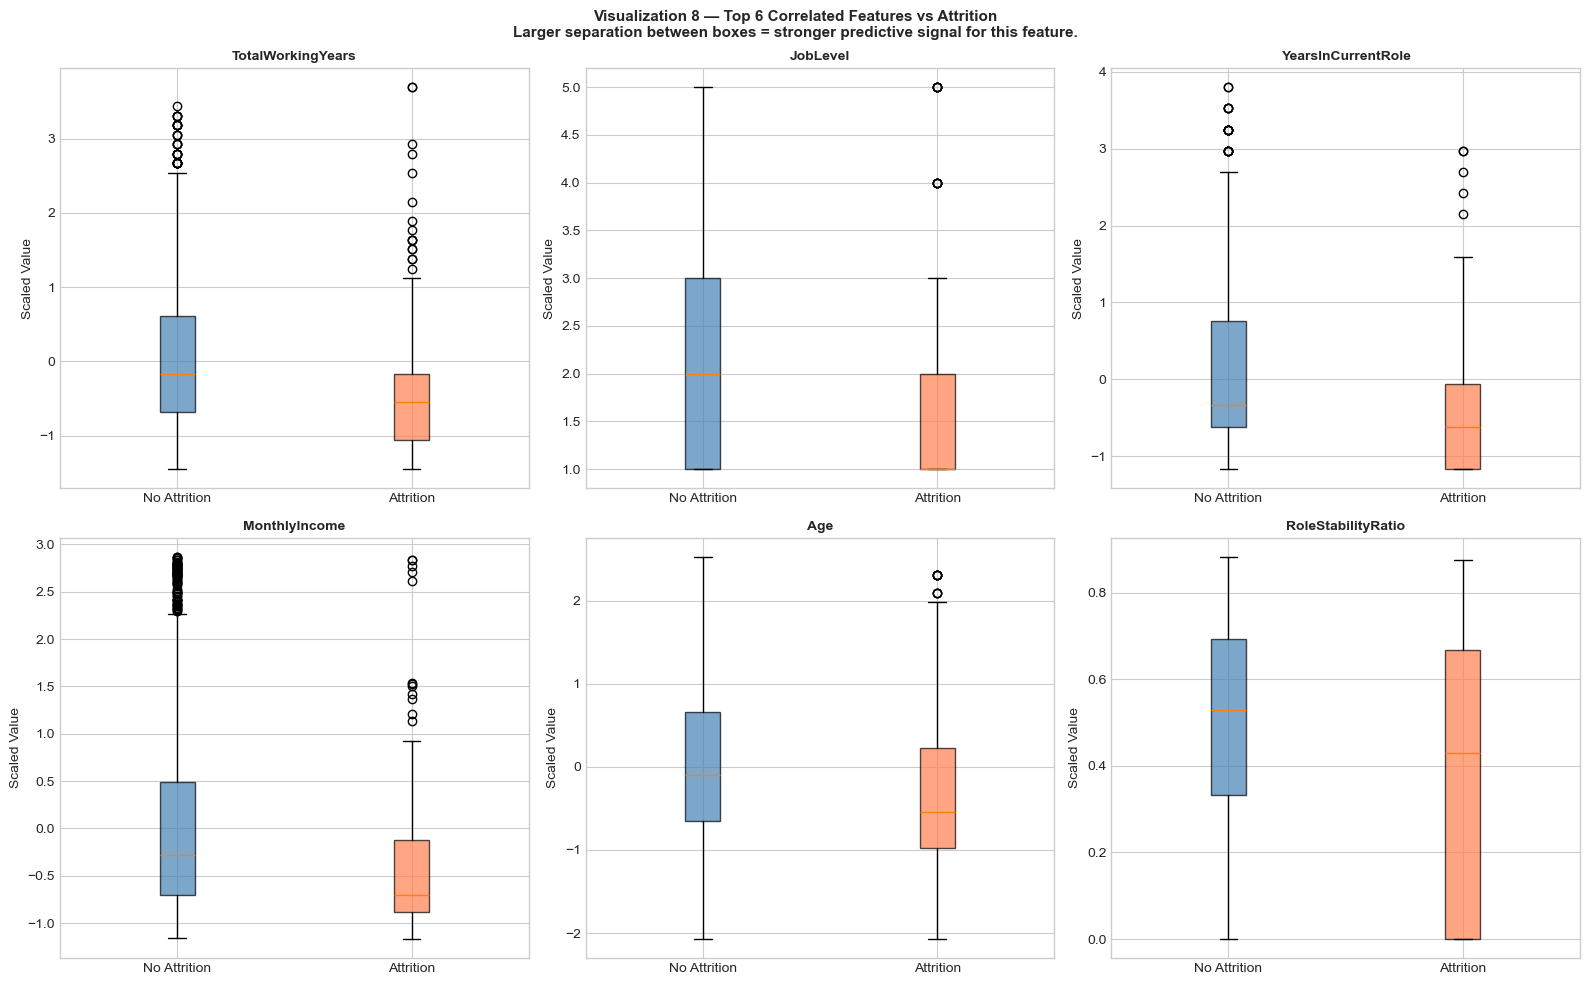

Visualization 8 saved.


In [24]:
# VISUALIZATION 8: Top 6 features vs Attrition — Box Plots
top6 = corr_with_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top6):
    bp = axes[i].boxplot(
        [df[df['Attrition'] == 0][col], df[df['Attrition'] == 1][col]],
        labels=['No Attrition', 'Attrition'],
        patch_artist=True
    )
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('coral');     bp['boxes'][1].set_alpha(0.7)
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Scaled Value')

plt.suptitle(
    'Visualization 8 — Top 6 Correlated Features vs Attrition\n'
    'Larger separation between boxes = stronger predictive signal for this feature.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/viz8_top_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 8 saved.')

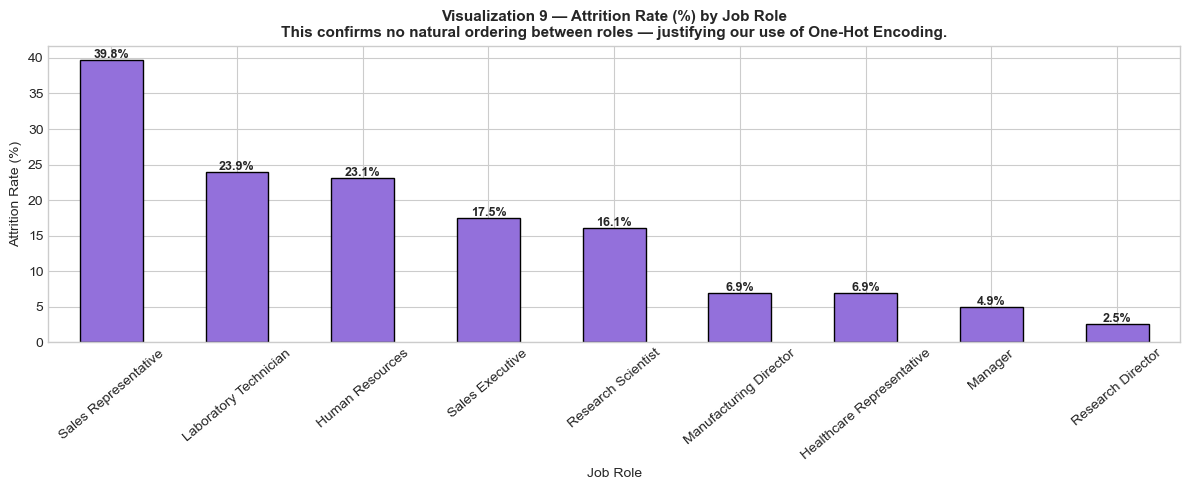

Visualization 9 saved.


In [25]:
# VISUALIZATION 9: Attrition rate by JobRole (using OHE output)
jobrole_attrition = {
    col.replace('JobRole_', ''): df[df[col] == 1]['Attrition'].mean() * 100
    for col in df.columns if col.startswith('JobRole_')
}
jobrole_series = pd.Series(jobrole_attrition).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
bars = jobrole_series.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_title(
    'Visualization 9 — Attrition Rate (%) by Job Role\n'
    'This confirms no natural ordering between roles — justifying our use of One-Hot Encoding.',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Job Role')
ax.set_ylabel('Attrition Rate (%)')
ax.tick_params(axis='x', rotation=40)
for i, v in enumerate(jobrole_series.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz9_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualization 9 saved.')

---
### 8 — Outlier Detection & Handling

We looked at all the numerical columns and noticed that `MonthlyIncome` and `TotalWorkingYears` have some pretty extreme values at the high end. Even though this is a synthetic dataset, those extremes can still mess with the scaler and pull the model's attention toward them.

To handle this, we went with **Winsorization** that basically capping values at the 1st and 99th percentiles instead of just deleting rows. We didn't want to lose any records (we only have 1,470), so capping made more sense than dropping.

We used IQR (Interquartile Range) to confirm which values actually qualify as outliers, then visualized before/after to make sure the capping actually made a difference. After capping, we re-standardized those two columns so they stay consistent with the rest of the scaled features.


MonthlyIncome: 114 outlier(s) found outside [-5291, 16581]
TotalWorkingYears: 63 outlier(s) found outside [-8, 28]


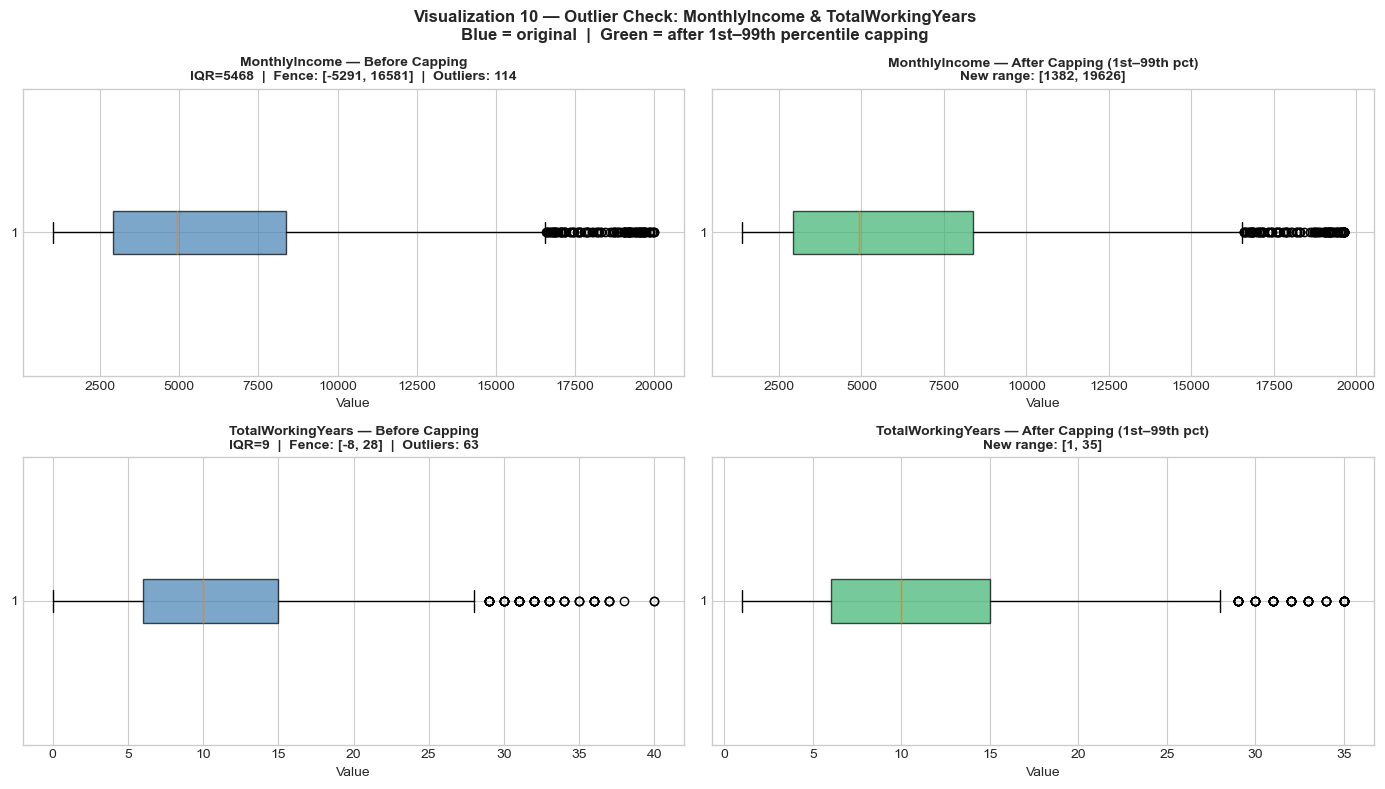

Visualization 10 saved.


In [26]:
# columns we suspect have extreme values worth checking
outlier_cols = ['MonthlyIncome', 'TotalWorkingYears']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(outlier_cols):
    raw_vals = df_raw[col]

    # calculate IQR boundaries to identify outliers
    Q1, Q3 = raw_vals.quantile(0.25), raw_vals.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR
    upper  = Q3 + 1.5 * IQR
    outliers = raw_vals[(raw_vals < lower) | (raw_vals > upper)]

    # left plot: original distribution before any capping
    axes[i*2].boxplot(raw_vals, vert=False, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i*2].set_title(f'{col} — Before Capping\n'
                        f'IQR={IQR:.0f}  |  Fence: [{lower:.0f}, {upper:.0f}]  |  Outliers: {len(outliers)}',
                        fontsize=10, fontweight='bold')
    axes[i*2].set_xlabel('Value')

    # right plot: after capping at 1st–99th percentile
    capped = raw_vals.clip(lower=raw_vals.quantile(0.01), upper=raw_vals.quantile(0.99))
    axes[i*2+1].boxplot(capped, vert=False, patch_artist=True,
                        boxprops=dict(facecolor='mediumseagreen', alpha=0.7))
    axes[i*2+1].set_title(f'{col} — After Capping (1st–99th pct)\n'
                           f'New range: [{capped.min():.0f}, {capped.max():.0f}]',
                           fontsize=10, fontweight='bold')
    axes[i*2+1].set_xlabel('Value')

    print(f'{col}: {len(outliers)} outlier(s) found outside [{lower:.0f}, {upper:.0f}]')

plt.suptitle('Visualization 10 — Outlier Check: MonthlyIncome & TotalWorkingYears\n'
             'Blue = original  |  Green = after 1st–99th percentile capping',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz10_outliers.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualization 10 saved.')


In [27]:
from sklearn.preprocessing import StandardScaler as SS

# cap each column and re-standardize so it stays consistent with other scaled features
for col in outlier_cols:
    raw_vals = df_raw[col].copy()

    # find 1st and 99th percentile boundaries
    p01 = raw_vals.quantile(0.01)
    p99 = raw_vals.quantile(0.99)

    # clip anything outside those bounds
    capped = raw_vals.clip(lower=p01, upper=p99)

    # re-fit a fresh scaler on the capped values and update df
    col_scaler = SS()
    df[col] = col_scaler.fit_transform(capped.values.reshape(-1, 1)).flatten()

    print(f'{col}: capped to [{p01:.0f}, {p99:.0f}] → re-scaled '
          f'(mean={df[col].mean():.4f}, std={df[col].std():.4f})')

print('\nDone. Both columns are now capped and re-standardized.')


MonthlyIncome: capped to [1382, 19626] → re-scaled (mean=-0.0000, std=1.0003)
TotalWorkingYears: capped to [1, 35] → re-scaled (mean=0.0000, std=1.0003)

Done. Both columns are now capped and re-standardized.


---
### 9 — Label Encoding

`BusinessTravel` is one of the columns that still has text values at this point, but it's different from the ones we one-hot encoded earlier. The difference is that this column actually has a meaningful order to it:

- `Non-Travel` → someone who never travels
- `Travel_Rarely` → travels once in a while
- `Travel_Frequently` → travels a lot

That progression matters. More travel = more stress = potentially higher chance of leaving. If we used One-Hot Encoding here, we'd throw away that ordering completely and treat all three as totally unrelated categories. Instead, we map them to 0, 1, 2 so the model can actually understand that `Travel_Frequently` represents a higher burden than `Non-Travel`.

The plot below confirms this is the right call and attrition rate clearly goes up as travel frequency increases.


Before encoding:
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
dtype: object

After encoding:
BusinessTravel
0     150
1    1043
2     277
Name: count, dtype: int64
dtype: int64


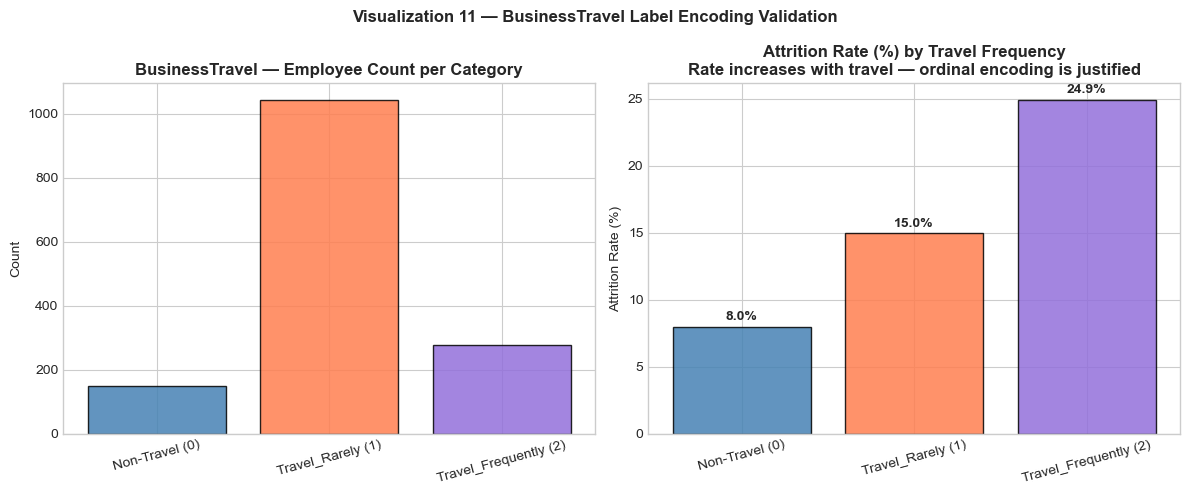

Visualization 11 saved.


In [28]:
# check what the column looks like before we touch it
print('Before encoding:')
print(df['BusinessTravel'].value_counts())
print(f'dtype: {df["BusinessTravel"].dtype}')

# map the categories to integers that reflect their natural order
travel_order = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
df['BusinessTravel'] = df['BusinessTravel'].map(travel_order)

print('\nAfter encoding:')
print(df['BusinessTravel'].value_counts().sort_index())
print(f'dtype: {df["BusinessTravel"].dtype}')

# Visualization 11: confirm the encoding makes sense
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left: how many employees fall into each travel category
counts = df['BusinessTravel'].value_counts().sort_index()
labels = ['Non-Travel (0)', 'Travel_Rarely (1)', 'Travel_Frequently (2)']
axes[0].bar(labels, counts.values, color=['steelblue', 'coral', 'mediumpurple'],
            edgecolor='black', alpha=0.85)
axes[0].set_title('BusinessTravel — Employee Count per Category', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# right: attrition rate per category. Should go up with travel if ordinal encoding is right
attrition_by_travel = df.groupby('BusinessTravel')['Attrition'].mean() * 100
axes[1].bar(labels, attrition_by_travel.values,
            color=['steelblue', 'coral', 'mediumpurple'], edgecolor='black', alpha=0.85)
for i, v in enumerate(attrition_by_travel.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Attrition Rate (%) by Travel Frequency\n'
                  'Rate increases with travel — ordinal encoding is justified',
                  fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Visualization 11 — BusinessTravel Label Encoding Validation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz11_businesstravel.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualization 11 saved.')


---
### 10 — Discretization

`Age` is already in the dataset as a scaled continuous feature, but we thought it would be useful to also create a grouped version of it. The reason is that the relationship between age and attrition probably isn't perfectly linear that a 22-year-old and a 29-year-old might behave similarly in terms of job-hopping, even though their raw ages are different. Grouping them together lets the model pick up on those generational patterns more easily.

We defined three bins based on what makes sense in careers:
- **Young (18–30):** early career, still exploring, more likely to leave
- **Middle-Aged (31–45):** more settled, established at a company
- **Senior (46–60):** closer to retirement, different motivations for leaving

We kept the original scaled `Age` column as well beacause this is just an extra feature, not a replacement.


AgeGroup distribution:
  0 (Young): 386 employees (26.3%)
  1 (Middle-Aged): 811 employees (55.2%)
  2 (Senior): 273 employees (18.6%)


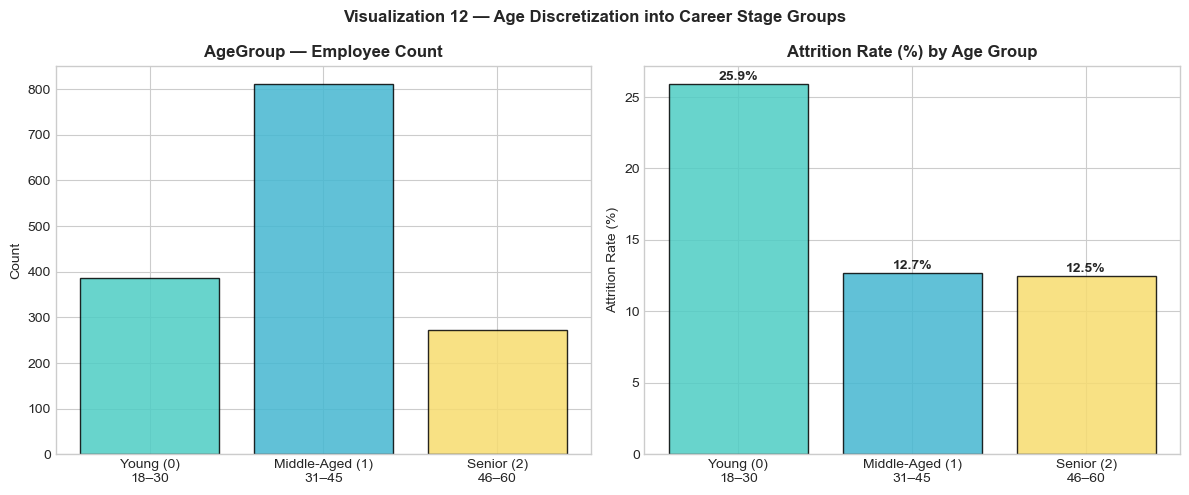

Visualization 12 saved.


In [29]:
# define age boundaries and corresponding group labels
bins   = [17, 30, 45, 60]
labels = ['Young', 'Middle-Aged', 'Senior']

# bin using the original (unscaled) age values so the boundaries make sense
df['AgeGroup'] = pd.cut(df_raw['Age'], bins=bins, labels=labels)

# convert group labels to ordinal integers (Young=0, Middle-Aged=1, Senior=2)
df['AgeGroup'] = df['AgeGroup'].map({'Young': 0, 'Middle-Aged': 1, 'Senior': 2})

# quick check of how employees are distributed across groups
print('AgeGroup distribution:')
for val, lbl in zip([0, 1, 2], labels):
    count = (df['AgeGroup'] == val).sum()
    pct   = count / len(df) * 100
    print(f'  {val} ({lbl}): {count} employees ({pct:.1f}%)')

# Visualization 12
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

age_labels = ['Young (0)\n18–30', 'Middle-Aged (1)\n31–45', 'Senior (2)\n46–60']

# left: size of each age group
counts = df['AgeGroup'].value_counts().sort_index()
axes[0].bar(age_labels, counts.values, color=['#4ecdc4', '#45b7d1', '#f7dc6f'],
            edgecolor='black', alpha=0.85)
axes[0].set_title('AgeGroup — Employee Count', fontweight='bold')
axes[0].set_ylabel('Count')

# right: attrition rate per group. Young employees should have the highest
attrition_by_age = df.groupby('AgeGroup')['Attrition'].mean() * 100
axes[1].bar(age_labels, attrition_by_age.values,
            color=['#4ecdc4', '#45b7d1', '#f7dc6f'], edgecolor='black', alpha=0.85)
for i, v in enumerate(attrition_by_age.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Attrition Rate (%) by Age Group', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')

plt.suptitle('Visualization 12 — Age Discretization into Career Stage Groups',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz12_agegroup.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualization 12 saved.')


---
### 11 — Feature Engineering

The dataset has three separate satisfaction columns: `EnvironmentSatisfaction`, `JobSatisfaction`, and `RelationshipSatisfaction`. Each one tells part of the story, but we think an employee who is unhappy across all three dimensions is much more likely to leave than someone who just has one low score.

So we created two new features:

- **`SatisfactionScore`** — the average of the three scores. Gives a single number that represents overall well being (range 1–4). Higher is better.
- **`LowSatisfactionFlag`** — a binary flag we set to 1 if that average drops to 2 or below. This is basically an "at risk" label we can use as an extra signal in classification.

We computed both of these from the original unscaled values in `df_raw` so that the 1–4 Likert scale stays meaningful for the threshold comparison.


New satisfaction features:
  SatisfactionScore  — min: 1.00, max: 4.00, mean: 2.72
  LowSatisfactionFlag — 289 employees flagged (19.7% of dataset)


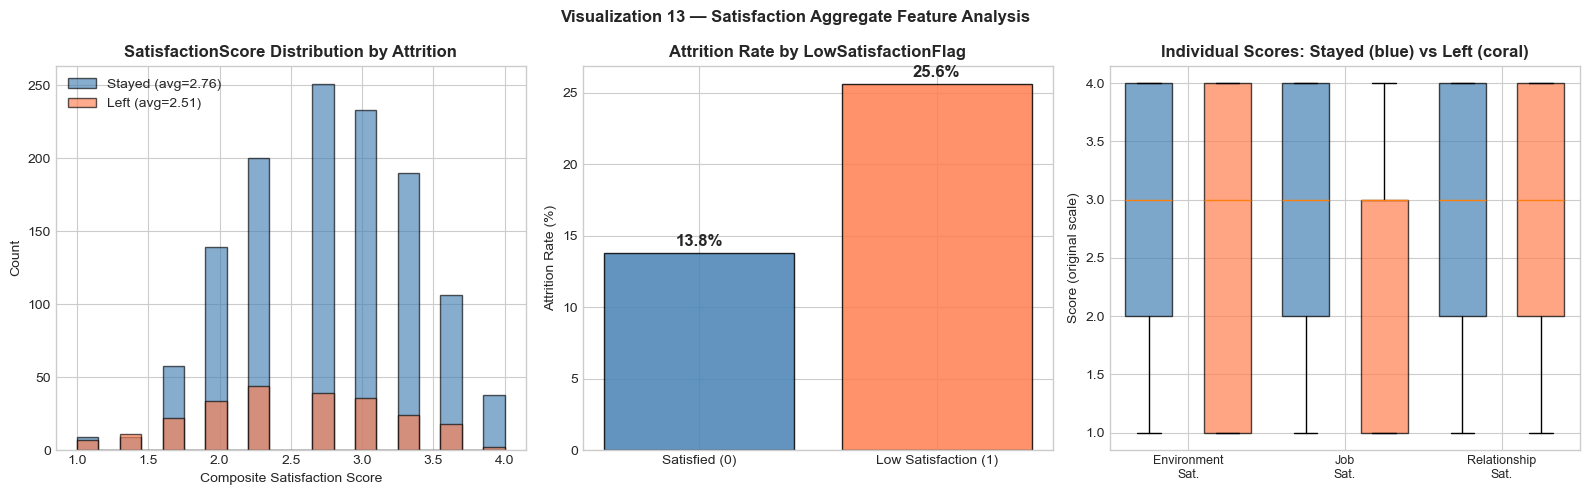

Visualization 13 saved.


In [30]:
# the three satisfaction columns we want to combine
sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction']

# compute the row-wise average using original values (1–4 scale)
raw_sat = df_raw[sat_cols].mean(axis=1)

# add composite score as a continuous feature
df['SatisfactionScore'] = raw_sat

# flag employees whose overall satisfaction is <= 2 as at risk
df['LowSatisfactionFlag'] = (raw_sat <= 2.0).astype(int)

# quick sanity check on what we just created
print('New satisfaction features:')
print(f'  SatisfactionScore  — min: {df["SatisfactionScore"].min():.2f}, '
      f'max: {df["SatisfactionScore"].max():.2f}, '
      f'mean: {df["SatisfactionScore"].mean():.2f}')
print(f'  LowSatisfactionFlag — {df["LowSatisfactionFlag"].sum()} employees flagged '
      f'({df["LowSatisfactionFlag"].mean()*100:.1f}% of dataset)')

# Visualization 13
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# left: distribution of composite score split by whether they left or stayed
no_attr  = df[df['Attrition'] == 0]['SatisfactionScore']
yes_attr = df[df['Attrition'] == 1]['SatisfactionScore']
axes[0].hist(no_attr,  bins=20, alpha=0.65, color='steelblue',
             edgecolor='black', label=f'Stayed (avg={no_attr.mean():.2f})')
axes[0].hist(yes_attr, bins=20, alpha=0.65, color='coral',
             edgecolor='black', label=f'Left (avg={yes_attr.mean():.2f})')
axes[0].set_title('SatisfactionScore Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Composite Satisfaction Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# middle: does the low satisfaction flag actually predict attrition?
flag_rates = df.groupby('LowSatisfactionFlag')['Attrition'].mean() * 100
axes[1].bar(['Satisfied (0)', 'Low Satisfaction (1)'],
            flag_rates.values, color=['steelblue', 'coral'], edgecolor='black', alpha=0.85)
for i, v in enumerate(flag_rates.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Attrition Rate by LowSatisfactionFlag', fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')

# right: side-by-side boxplots for each individual score (stayed vs left)
data_no  = [df[df['Attrition'] == 0][c].values for c in sat_cols]
data_yes = [df[df['Attrition'] == 1][c].values for c in sat_cols]
bp1 = axes[2].boxplot(data_no,  positions=[1, 3, 5], widths=0.6,
                      patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
bp2 = axes[2].boxplot(data_yes, positions=[2, 4, 6], widths=0.6,
                      patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.7))
axes[2].set_xticks([1.5, 3.5, 5.5])
axes[2].set_xticklabels(['Environment\nSat.', 'Job\nSat.', 'Relationship\nSat.'], fontsize=9)
axes[2].set_title('Individual Scores: Stayed (blue) vs Left (coral)', fontweight='bold')
axes[2].set_ylabel('Score (original scale)')

plt.suptitle('Visualization 13 — Satisfaction Aggregate Feature Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/viz13_satisfaction.png', dpi=120, bbox_inches='tight')
plt.show()
print('Visualization 13 saved.')


---
## 5. Preprocessed Dataset

The cell below saves the preprocessed dataset as a CSV that is ready for modeling.

In [31]:
# Preprocessing Pipeline completed. Saving the final cleaned and engineered dataset to CSV.
final_filename = 'Dataset/preprocessed_data.csv'
df.to_csv(final_filename, index=False)

print(f'Saved: {final_filename}')
print(f'  Rows:    {df.shape[0]}')
print(f'  Columns: {df.shape[1]}')

Saved: Dataset/preprocessed_data.csv
  Rows:    1470
  Columns: 54


---
## 6. Key Insights & Challenges

### Key Insights

1. **4 columns dropped immediately** — `EmployeeCount`, `Over18`, `StandardHours`, and `EmployeeNumber` were all either constant or just IDs. They'd add zero value to a model and would only increase noise.

2. **The dataset is clean, but the classes are imbalanced** — No missing values at all, which is nice. But only about 16.1% of employees actually left (`Attrition = 1`). That means a model that always predicts "stays" would get 84% accuracy without learning anything useful. Phase 2 needs to handle this carefully with stratified splits and class weights.

3. **One-Hot Encoding was the right call for Department and JobRole** — The attrition rates across job roles jump around in no particular order (Sales Reps are around 40%, Research Directors are under 3%). There's no numeric ranking that would make sense here, so OHE was the correct choice.

4. **Label Encoding made more sense for BusinessTravel** — Unlike the other categorical columns, travel frequency has a clear order, and the attrition rate actually does go up as you go from Non-Travel → Rarely → Frequently. Ordinal encoding captures that, but OHE would have thrown it away.

5. **Ratio features added useful context** — `PromotionRatio` and `IncomePerYear` both showed visible differences between employees who left and those who stayed. Career stagnation and lower income relative to experience seem to be real contributing factors.

6. **Combining the satisfaction scores worked well** — Looking at `EnvironmentSatisfaction`, `JobSatisfaction`, and `RelationshipSatisfaction` individually is fine, but combining them into a single score and flagging employees below 2.0 gave a stronger attrition signal than any one of them alone.

7. **Younger employees leave at much higher rates** — The age group breakdown confirmed that employees between 18 and 30 have noticeably higher attrition. Discretizing age makes this pattern explicitly available to models that might not pick it up from the raw continuous value.

8. **Scaling was necessary** — The income column ranged from roughly 1,000 to 20,000 while JobLevel only goes from 1 to 5. Without StandardScaler, any distance-based model would have basically ignored everything except income.

### Challenges

1. **Class imbalance** is the biggest issue going into Phase 2. Accuracy alone will be a misleading metric, we need F1, precision/recall, and proper stratified evaluation.
2. **Computing ratios from raw data** — since some columns were already scaled when we got to Section 6, we had to go back to `df_raw` for the ratio calculations. A cleaner approach would have been to compute all engineered features before scaling.
3. **OHE adds a lot of columns** — `JobRole` alone created 9 new binary columns. If the model starts struggling with dimensionality, PCA or feature selection would be a reasonable next step in Phase 2.
4. **Re-standardizing after outlier capping** — capping and then re-scaling `MonthlyIncome` and `TotalWorkingYears` means their distributions differ slightly from the other scaled columns. It's a reasonable trade-off but worth noting.
5. **The dataset is synthetic** — IBM generated this data artificially, which means the patterns in it are too clean than real HR data would ever be. A model trained on it might perform worse when applied to a real company's messy and inconsistent data.